In [29]:
import os, sys
PROJECT_ROOT = os.path.abspath("..")  # 从 notebook/ 回到项目根目录
sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, "IEEE")
LOG_DIR  = os.path.join(PROJECT_ROOT, "log")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("LOG_DIR:", LOG_DIR)

PROJECT_ROOT: /root/ADHD-EEG-ViT-myversion
DATA_DIR: /root/ADHD-EEG-ViT-myversion/IEEE
LOG_DIR: /root/ADHD-EEG-ViT-myversion/log


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from utils import (
    ignore_warnings,
    fix_random_seed,
    device,
    clear_cache,
    join_drive_path,
    log_json,
    train_with_kfold,
    WarmupScheduler,
    evaluate,
    Config,
    IEEEDataConfig,
    EEGDataset,
)
from models.transformer import TransformerConfig, ViTransformer

ignore_warnings()
fix_random_seed(42)
#device = device(force_cuda=True)
#print("Device:", device)
device = device(force_cuda=torch.cuda.is_available())
print("Device:", device)

Device: cuda


In [31]:
config = Config(
    name="ieee transformer",
    batch=8,
    epochs=50,
    lr=1e-3,
    enable_fp16=True,
    grad_step=4,
    warmup_steps=30,
    lr_decay_factor=0.5,
    weight_decay=1e-3,
    patience=30,
)
config.add(k_folds=5)
data_config = IEEEDataConfig()
model_config = TransformerConfig(
    embed_dim=64,
    num_heads=4,
    num_blocks=4,
    block_hidden_dim=128,
    fc_hidden_dim=32,
    dropout=0.1,
)

print("ID:", config.id)
print("Name:", config.name)

ID: 260311225831101899
Name: ieee-transformer


In [32]:
train_data_path = os.path.join(DATA_DIR, data_config.train)  # train.pt
val_data_path   = os.path.join(DATA_DIR, data_config.val)    # val.pt

train_data = torch.load(train_data_path, weights_only=True)
val_data = torch.load(val_data_path, weights_only=True)

# Concat Train-set and Validation-set for Cross validation
signals = torch.cat([train_data["data"], val_data["data"]], dim=0)
labels = torch.cat([train_data["label"], val_data["label"]], dim=0)

train_dataset = EEGDataset({"data": signals, "label": labels})

In [33]:
model_param = {
    "input_channel": data_config.channels,
    "seq_length": data_config.length,
    "embed_dim": model_config.embed_dim,
    "num_heads": model_config.num_heads,
    "num_blocks": model_config.num_blocks,
    "block_hidden_dim": model_config.block_hidden_dim,
    "fc_hidden_dim": model_config.fc_hidden_dim,
    "num_classes": data_config.num_classes,
    "dropout_p": model_config.dropout,
    
    # "use_channel_attn": False,
   
    # "use_channel_attn": True,           #3.5channelattention动态态
    # "channel_attn_type": "dynamic",
    # "channel_attn_reduction": 4,

    "use_channel_attn": True, 
    "channel_attn_type": "eca",      #3.11 eca attention
    "eca_kernel_size": 3,

    # "use_channel_attn": True,           #3.5channelattention静态
    # "channel_attn_type": "static",
}
# # ===== 3.10加噪声开关 =====
# enable_train_noise = False
# train_noise_type = None
# train_noise_level = 0.0

# enable_val_noise = False      
# val_noise_type = "channel_dropout"    #None或"gaussian"
# val_noise_level = 0.3
# # =========================
criterion = nn.CrossEntropyLoss()
check_point, best_model_path = train_with_kfold(          #3.9比原句多加了一个“fold_results”打印每个fold结果
    k_folds=config.k_folds,
    model_class=ViTransformer,
    device=device,
    model_path=config.model_path,
    optimizer_class=optim.Adam,
    criterion=criterion,
    epochs=config.epochs,
    train_dataset=train_dataset,
    batch=config.batch,
    gradient_step=config.grad_step,
    patience=config.patience,
    model_params=model_param,
    optimizer_params={"lr": config.lr, "weight_decay": config.weight_decay},
    enable_fp16=config.enable_fp16,
    scheduler_class=WarmupScheduler,
    scheduler_params={
        "lr": config.lr,
        "warmup_steps": config.warmup_steps,
        "decay_factor": config.lr_decay_factor,
    },

    #     # ===== 新增：噪声参数 =====
    # enable_train_noise=enable_train_noise,
    # train_noise_type=train_noise_type,
    # train_noise_level=train_noise_level,
    # enable_val_noise=enable_val_noise,
    # val_noise_type=val_noise_type,
    # val_noise_level=val_noise_level,
    # channel_dim=1,
)



===== Fold 1 =====


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1, Train-Loss: 0.93435,  Val-Loss: 1.07738
Epoch 2, Train-Loss: 0.91082,  Val-Loss: 1.00994
Epoch 3, Train-Loss: 0.84684,  Val-Loss: 0.91840
Epoch 4, Train-Loss: 0.79769,  Val-Loss: 0.81852
Epoch 5, Train-Loss: 0.75541,  Val-Loss: 0.72852
Epoch 6, Train-Loss: 0.70633,  Val-Loss: 0.67063
Epoch 7, Train-Loss: 0.68853,  Val-Loss: 0.63876
Epoch 8, Train-Loss: 0.69599,  Val-Loss: 0.62251
Epoch 9, Train-Loss: 0.70258,  Val-Loss: 0.61454
Epoch 10, Train-Loss: 0.73106,  Val-Loss: 0.61037
Epoch 11, Train-Loss: 0.71860,  Val-Loss: 0.60853
Epoch 12, Train-Loss: 0.70331,  Val-Loss: 0.61198
Epoch 13, Train-Loss: 0.66384,  Val-Loss: 0.61526
Epoch 14, Train-Loss: 0.66141,  Val-Loss: 0.62372
Epoch 15, Train-Loss: 0.66756,  Val-Loss: 0.63352
Epoch 16, Train-Loss: 0.68552,  Val-Loss: 0.64501
Epoch 17, Train-Loss: 0.64677,  Val-Loss: 0.64125
Epoch 18, Train-Loss: 0.61957,  Val-Loss: 0.63484
Epoch 19, Train-Loss: 0.59401,  Val-Loss: 0.62202
Epoch 20, Train-Loss: 0.58234,  Val-Loss: 0.59623
Epoch 21,

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1, Train-Loss: 0.68990,  Val-Loss: 0.74894
Epoch 2, Train-Loss: 0.68875,  Val-Loss: 0.72656
Epoch 3, Train-Loss: 0.65384,  Val-Loss: 0.70539
Epoch 4, Train-Loss: 0.64180,  Val-Loss: 0.68840
Epoch 5, Train-Loss: 0.64663,  Val-Loss: 0.67528
Epoch 6, Train-Loss: 0.63605,  Val-Loss: 0.66646
Epoch 7, Train-Loss: 0.65161,  Val-Loss: 0.65931
Epoch 8, Train-Loss: 0.61477,  Val-Loss: 0.65515
Epoch 9, Train-Loss: 0.61766,  Val-Loss: 0.64111
Epoch 10, Train-Loss: 0.56185,  Val-Loss: 0.63149
Epoch 11, Train-Loss: 0.56399,  Val-Loss: 0.61336
Epoch 12, Train-Loss: 0.54405,  Val-Loss: 0.59346
Epoch 13, Train-Loss: 0.53602,  Val-Loss: 0.58140
Epoch 14, Train-Loss: 0.54196,  Val-Loss: 0.56985
Epoch 15, Train-Loss: 0.50861,  Val-Loss: 0.56078
Epoch 16, Train-Loss: 0.44986,  Val-Loss: 0.53513
Epoch 17, Train-Loss: 0.46059,  Val-Loss: 0.52371
Epoch 18, Train-Loss: 0.43655,  Val-Loss: 0.50422
Epoch 19, Train-Loss: 0.45982,  Val-Loss: 0.49291
Epoch 20, Train-Loss: 0.42340,  Val-Loss: 0.49191
Epoch 21,

...

Epoch 1, Train-Loss: 0.81534,  Val-Loss: 0.87157
Epoch 2, Train-Loss: 0.81567,  Val-Loss: 0.83913
Epoch 3, Train-Loss: 0.78817,  Val-Loss: 0.75512
Epoch 4, Train-Loss: 0.71819,  Val-Loss: 0.69230
Epoch 5, Train-Loss: 0.70476,  Val-Loss: 0.66270
Epoch 6, Train-Loss: 0.69687,  Val-Loss: 0.66407
Epoch 7, Train-Loss: 0.70443,  Val-Loss: 0.66299
Epoch 8, Train-Loss: 0.70821,  Val-Loss: 0.66162
Epoch 9, Train-Loss: 0.70883,  Val-Loss: 0.66547
Epoch 10, Train-Loss: 0.68287,  Val-Loss: 0.67077
Epoch 11, Train-Loss: 0.68472,  Val-Loss: 0.67436
Epoch 12, Train-Loss: 0.68045,  Val-Loss: 0.67316
Epoch 13, Train-Loss: 0.67991,  Val-Loss: 0.67033
Epoch 14, Train-Loss: 0.68979,  Val-Loss: 0.66998
Epoch 15, Train-Loss: 0.68391,  Val-Loss: 0.66810
Epoch 16, Train-Loss: 0.68181,  Val-Loss: 0.66603
Epoch 17, Train-Loss: 0.68460,  Val-Loss: 0.66547
Epoch 18, Train-Loss: 0.68686,  Val-Loss: 0.66432
Epoch 19, Train-Loss: 0.68453,  Val-Loss: 0.66671
Epoch 20, Train-Loss: 0.68396,  Val-Loss: 0.66861
Epoch 21,

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1, Train-Loss: 0.75172,  Val-Loss: 0.72541
Epoch 2, Train-Loss: 0.74257,  Val-Loss: 0.71315
Epoch 3, Train-Loss: 0.70428,  Val-Loss: 0.68988
Epoch 4, Train-Loss: 0.67880,  Val-Loss: 0.69924
Epoch 5, Train-Loss: 0.68099,  Val-Loss: 0.72934
Epoch 6, Train-Loss: 0.67798,  Val-Loss: 0.73716
Epoch 7, Train-Loss: 0.69203,  Val-Loss: 0.71954
Epoch 8, Train-Loss: 0.68028,  Val-Loss: 0.69952
Epoch 9, Train-Loss: 0.66478,  Val-Loss: 0.69479
Epoch 10, Train-Loss: 0.68957,  Val-Loss: 0.69290
Epoch 11, Train-Loss: 0.68488,  Val-Loss: 0.69066
Epoch 12, Train-Loss: 0.66976,  Val-Loss: 0.69250
Epoch 13, Train-Loss: 0.67730,  Val-Loss: 0.69533
Epoch 14, Train-Loss: 0.68854,  Val-Loss: 0.70833
Epoch 15, Train-Loss: 0.67048,  Val-Loss: 0.70239
Epoch 16, Train-Loss: 0.66774,  Val-Loss: 0.70178
Epoch 17, Train-Loss: 0.67792,  Val-Loss: 0.69675
Epoch 18, Train-Loss: 0.68026,  Val-Loss: 0.69062
Epoch 19, Train-Loss: 0.67067,  Val-Loss: 0.69237
Epoch 20, Train-Loss: 0.66638,  Val-Loss: 0.69874
Epoch 21,

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1, Train-Loss: 0.69226,  Val-Loss: 0.71382
Epoch 2, Train-Loss: 0.66884,  Val-Loss: 0.71804
Epoch 3, Train-Loss: 0.67211,  Val-Loss: 0.72918
Epoch 4, Train-Loss: 0.69455,  Val-Loss: 0.74520
Epoch 5, Train-Loss: 0.69079,  Val-Loss: 0.72055
Epoch 6, Train-Loss: 0.66940,  Val-Loss: 0.70546
Epoch 7, Train-Loss: 0.68957,  Val-Loss: 0.70499
Epoch 8, Train-Loss: 0.67517,  Val-Loss: 0.70936
Epoch 9, Train-Loss: 0.67533,  Val-Loss: 0.72712
Epoch 10, Train-Loss: 0.67721,  Val-Loss: 0.73960
Epoch 11, Train-Loss: 0.67794,  Val-Loss: 0.72183
Epoch 12, Train-Loss: 0.66903,  Val-Loss: 0.71027
Epoch 13, Train-Loss: 0.67699,  Val-Loss: 0.71656
Epoch 14, Train-Loss: 0.68319,  Val-Loss: 0.72622
Epoch 15, Train-Loss: 0.68178,  Val-Loss: 0.71840
Epoch 16, Train-Loss: 0.67583,  Val-Loss: 0.71626
Epoch 17, Train-Loss: 0.67369,  Val-Loss: 0.72256
Epoch 18, Train-Loss: 0.67637,  Val-Loss: 0.71959
Epoch 19, Train-Loss: 0.67569,  Val-Loss: 0.71537
Epoch 20, Train-Loss: 0.67704,  Val-Loss: 0.70895
Epoch 21,

In [34]:
# # ===== Cross-validation summary + training curve =====

# import numpy as np
# import matplotlib.pyplot as plt

# print("===== Fold Results =====")

# for r in fold_results:
#     print(
#         f"Fold {r['fold']} | "
#         f"best_epoch={r['best_epoch']} | "
#         f"val_loss={r['val_loss']:.6f} | "
#         f"val_acc={r['val_acc']:.4f}"
#     )

# # ===== Mean ± Std =====
# val_losses = [r["val_loss"] for r in fold_results]
# val_accs = [r["val_acc"] for r in fold_results]

# print("\n===== Cross-validation Mean ± Std =====")
# print(f"val_loss: {np.mean(val_losses):.6f} ± {np.std(val_losses):.6f}")
# print(f"val_acc : {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")

# # ===== Choose one fold to inspect training curves =====
# fold_id = 0   # 可以改成 1,2,3,4 看不同 fold

# h = fold_results[fold_id]["history"]

# print(f"\n===== Training history for Fold {fold_results[fold_id]['fold']} =====")

# print("train_loss:", h["train_loss"])
# print("val_loss:", h["val_loss"])
# print("train_acc:", h["train_acc"])
# print("val_acc:", h["val_acc"])

# # ===== Plot curves =====
# epochs = range(1, len(h["train_loss"]) + 1)

# plt.figure(figsize=(10,4))

# plt.subplot(1,2,1)
# plt.plot(epochs, h["train_loss"], label="train_loss")
# plt.plot(epochs, h["val_loss"], label="val_loss")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()

# plt.subplot(1,2,2)
# plt.plot(epochs, h["train_acc"], label="train_acc")
# plt.plot(epochs, h["val_acc"], label="val_acc")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy")
# plt.legend()

# plt.tight_layout()
# plt.show()

In [35]:
config.epochs = check_point
config.model_path = best_model_path

print("Best model path:", join_drive_path("log", config.model_path))
print("Model checkpoint:", config.epochs)

Best model path: /root/ADHD-EEG-ViT-myversion/log/ieee-transformer_260311225831101899_2.pt
Model checkpoint: 42


In [36]:
# clear_cache()

# trained_weights = torch.load(os.path.join(LOG_DIR, config.model_path), weights_only=True, map_location=device)

# model = ViTransformer(**model_param)
# model.load_state_dict(trained_weights)

import os
import torch

clear_cache()

# config.model_path 现在打印出来已经是一个绝对路径（Best model path 那行）
real_model_path = config.model_path
print("Loading model from:", real_model_path)
assert os.path.exists(real_model_path), f"Model file not found: {real_model_path}"

# 先加载到 CPU，避免加载阶段就占用/冲击 GPU
state_dict = torch.load(real_model_path, map_location="cpu")  # 不用 weights_only

model = ViTransformer(**model_param)
model.load_state_dict(state_dict)

# 再把模型搬到你之前选择的 device（cuda 或 cpu）
model = model.to(device)
model.eval()

Loading model from: ieee-transformer_260311225831101899_2.pt


ViTransformer(
  (chan_attn): ECALayer1D(
    (avg_pool): AdaptiveAvgPool1d(output_size=1)
    (conv): Conv1d(1, 1, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (sigmoid): Sigmoid()
  )
  (proj): Conv1d(19, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (transformer): Transformer(
    (encoder): ModuleList(
      (0-3): 4 x AttentionBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (feedforward): Sequential(
          (0): Linear(in_features=64, out_features=128, bias=True)
          (1): ReLU()
          (2): Linear(in_features=128, out_features=64, bias=True)
        )
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
    (global_max_pool): Sequential(
      (0): AdaptiveMaxPool1d(output_size=1)
      (1): Dropout(p=0.1, inplace=False)
    )
    (fc)

In [37]:
#test_data_path = join_drive_path("data", data_config.test)
#test_dataset = EEGDataset(test_data_path)

test_data_path = os.path.join(DATA_DIR, data_config.test)  # test.pt
test_data = torch.load(test_data_path, weights_only=True)
test_dataset = EEGDataset(test_data)

test_dataloader = DataLoader(test_dataset, batch_size=config.batch)

metrics = evaluate(model, device, test_dataloader)

print(f"Accuracy: {metrics['accuracy']:.3f}")
print(f"F1-Score: {metrics['f1-score']:.3f}")
print(f"Recall: {metrics['recall']:.3f}")
print(f"AUC: {metrics['auc']:.3f}")

===== Debug: first 10 samples =====
sample 00 | true=1 | pred=1 | prob=[0.3062631  0.69373685]
sample 01 | true=1 | pred=1 | prob=[0.2872607 0.7127393]
sample 02 | true=1 | pred=1 | prob=[0.32919505 0.6708049 ]
sample 03 | true=1 | pred=1 | prob=[0.30596042 0.6940396 ]
sample 04 | true=1 | pred=1 | prob=[0.40834403 0.59165597]
sample 05 | true=1 | pred=1 | prob=[0.29246676 0.70753324]
sample 06 | true=1 | pred=1 | prob=[0.2980147 0.7019853]
sample 07 | true=1 | pred=1 | prob=[0.3060848  0.69391525]
sample 08 | true=1 | pred=1 | prob=[0.29664826 0.7033518 ]
sample 09 | true=1 | pred=1 | prob=[0.3139516 0.6860484]
Correct: 34/36
Accuracy: 0.9444
Accuracy: 0.944
F1-Score: 0.952
Recall: 0.952
AUC: 0.981


Extracted features shape: (36, 32)
Labels shape: (36,)


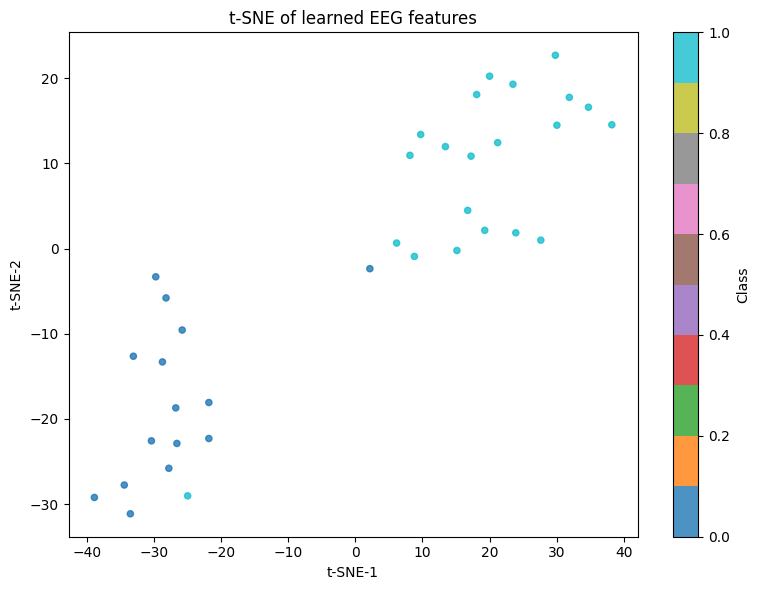

In [38]:
# 3.9===== t-SNE on learned features =====
# 放在“Cell 7（test_dataloader + evaluate）”后面即可
# 作用：提取 ViTransformer -> Transformer.fc[1] 的特征，并做 2D t-SNE 可视化

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

model.eval()
model.to(device)

all_features = []
all_labels = []
_cached_feats = []

def _feat_hook(module, inputs, output):
    # output shape: [B, fc_hidden_dim]
    _cached_feats.append(output.detach().cpu())

# hook 到 Transformer 分类头第一层 Linear
# transformer.py 里 self.fc = [Flatten, Linear, ReLU, Dropout, Linear]
hook_handle = model.transformer.fc[1].register_forward_hook(_feat_hook)

with torch.no_grad():
    for batch in test_dataloader:
        # 兼容几种 batch 格式
        if isinstance(batch, (list, tuple)) and len(batch) == 2 and torch.is_tensor(batch[0]):
            x, y = batch
        elif isinstance(batch, dict):
            x, y = batch["data"], batch["label"]
        elif isinstance(batch, list) and len(batch) > 0 and isinstance(batch[0], dict):
            x = torch.stack([b["data"] for b in batch], dim=0)
            y = torch.tensor([b["label"] for b in batch])
        else:
            raise TypeError(f"Unrecognized batch structure: {type(batch)}")

        x = x.to(device)

        # 前向传播，触发 hook
        _ = model(x)

        # 取出当前 batch 的特征
        feat = _cached_feats.pop(0)   # [B, fc_hidden_dim]
        all_features.append(feat.numpy())
        all_labels.append(y.detach().cpu().numpy() if torch.is_tensor(y) else np.array(y))

hook_handle.remove()

features = np.concatenate(all_features, axis=0)
labels = np.concatenate(all_labels, axis=0)

print("Extracted features shape:", features.shape)
print("Labels shape:", labels.shape)

# 可选：先标准化，再做 t-SNE
features_std = StandardScaler().fit_transform(features)

# perplexity 要小于样本数，做个稳妥保护
n_samples = len(features_std)
perplexity = min(30, max(5, n_samples // 10))
if perplexity >= n_samples:
    perplexity = max(2, n_samples - 1)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate="auto",
    init="pca",
    random_state=42
)

features_2d = tsne.fit_transform(features_std)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels,
    cmap="tab10",
    s=20,
    alpha=0.8
)

plt.title("t-SNE of learned EEG features")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()

In [39]:
json_path = join_drive_path("log", f"{config.name}_{config.id}.json")
log_json(
    json_path, config=config, data=data_config, model=model_config, metrics=metrics
)

{'config': {'name': 'ieee-transformer',
  'batch': 8,
  'epochs': 42,
  'lr': 0.001,
  'enable_fp16': True,
  'grad_step': 4,
  'warmup_steps': 30,
  'lr_decay_factor': 0.5,
  'weight_decay': 0.001,
  'patience': 30,
  'id': '260311225831101899',
  'model_path': 'ieee-transformer_260311225831101899_2.pt',
  'k_folds': 5},
 'data': {'tag': 'IEEE_23',
  'train': 'ieee_train.pt',
  'test': 'ieee_test.pt',
  'val': 'ieee_val.pt',
  'channels': 19,
  'length': 9250,
  'num_classes': 2},
 'model': {'embed_dim': 64,
  'num_heads': 4,
  'num_blocks': 4,
  'block_hidden_dim': 128,
  'fc_hidden_dim': 32,
  'dropout': 0.1},
 'metrics': {'accuracy': 0.9444444444444444,
  'f1-score': 0.9523809523809523,
  'recall': 0.9523809523809523,
  'auc': 0.9809523809523809}}

In [40]:
# 3.5改 检测channel-attention是否被启用取一个 batch 数据
batch = next(iter(test_dataloader))
print("batch type:", type(batch))
print("batch len:", len(batch) if hasattr(batch, "__len__") else None)

# 情况 A: (x, y) 或 [x, y]
if isinstance(batch, (list, tuple)) and len(batch) == 2 and torch.is_tensor(batch[0]):
    x, y = batch
    x = x.to(device)

# 情况 B: list[dict]
elif isinstance(batch, list) and len(batch) > 0 and isinstance(batch[0], dict):
    # 把 list[dict] 手动拼成 batch tensor（假设每个样本都有 "data"）
    x = torch.stack([b["data"] for b in batch], dim=0).to(device)

# 情况 C: dict（你原本写法适用）
elif isinstance(batch, dict):
    x = batch["data"].to(device)

else:
    raise TypeError(f"Unrecognized batch structure: {type(batch)} / example element: {type(batch[0]) if isinstance(batch, list) and batch else None}")

batch type: <class 'list'>
batch len: 2


In [41]:
#3.5 改
import re
from docx import Document

DOCX_PATH = "/root/ADHD-EEG-ViT-myversion/data_raw/Channel_Labels.docx"

def extract_channels_from_docx(docx_path):
    doc = Document(docx_path)
    tokens = []

    # 1) 读段落
    for p in doc.paragraphs:
        txt = p.text.strip()
        if txt:
            tokens.append(txt)

    # 2) 读表格（很多 docx 会把通道名放表格里）
    for table in doc.tables:
        for row in table.rows:
            for cell in row.cells:
                txt = cell.text.strip()
                if txt:
                    tokens.append(txt)

    # 3) 从文本里提取像 EEG 通道名的 token
    # 覆盖常见 10-20: Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3/T4/T5/T6, T7/T8, P7/P8, Fz/Cz/Pz 等
    pattern = re.compile(r"\b(?:Fp[12]|AF[34z]?|F[1-8z]|FC[1-6z]|C[1-6z]|CP[1-6z]|P[1-8z]|PO[1-8z]|O[12z]|T[3-8]|TP[7-8]|FT[7-8])\b", re.IGNORECASE)

    found = []
    for txt in tokens:
        found.extend(pattern.findall(txt))

    # 4) 保留原出现顺序去重 + 统一大小写格式（首字母大写，p 保持小写的通用写法）
    def normalize(ch):
        ch = ch.strip()
        ch = ch[0].upper() + ch[1:]  # 粗略标准化
        ch = ch.replace("FP", "Fp")  # 处理 Fp
        return ch

    ch_names = []
    seen = set()
    for ch in found:
        ch = normalize(ch)
        if ch not in seen:
            seen.add(ch)
            ch_names.append(ch)

    return ch_names

ch_names = extract_channels_from_docx(DOCX_PATH)
print("Extracted channels:", ch_names)
print("Count:", len(ch_names))

Extracted channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz']
Count: 19


Attention shape: torch.Size([4, 19])
Weight shape: (19,)


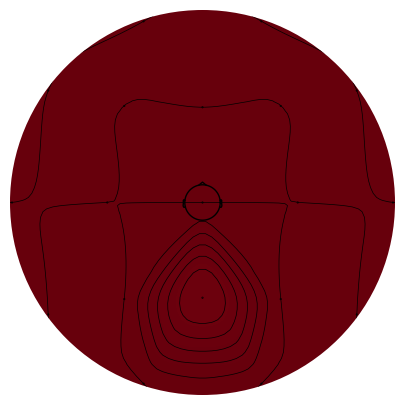

[1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        0.9851286]
min: 0.9851286
max: 1.0
range: 0.0148714185
variance: 1.1027322e-05


In [42]:
#3.5改
import os
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# 1) 取 attention 权重（长度=19）
attn = model.last_channel_attn

if attn is None:
    raise RuntimeError("model.last_channel_attn is None，请先 forward 一次模型。")

# dynamic attention: [B, 19]
if attn.dim() == 2:
    w = attn.mean(dim=0).detach().cpu().numpy()

# static gating: [19]
elif attn.dim() == 1:
    w = attn.detach().cpu().numpy()

else:
    raise ValueError(f"Unexpected attention shape: {attn.shape}")

print("Attention shape:", attn.shape)
print("Weight shape:", w.shape)

assert len(ch_names) == 19 and len(w) == 19, (len(ch_names), w.shape)

# 2) 读 .ced 坐标文件（你项目根目录里那个）
CED_PATH = "/root/ADHD-EEG-ViT-myversion/data_raw/Standard-10-20-Cap19new.ced"
df = pd.read_csv(CED_PATH, sep="\t")

# 你 preprocess 用过的坐标转换：[-Y, X, Z]
ch_pos_all = {
    row["labels"]: [-row["Y"], row["X"], row["Z"]]
    for _, row in df[["labels", "X", "Y", "Z"]].iterrows()
}

# 3) 只取你这 19 个通道的位置
missing = [ch for ch in ch_names if ch not in ch_pos_all]
if missing:
    raise ValueError(f"Channels not found in CED: {missing}\n"
                     f"Tip: 可能是 T3/T4 vs T7/T8 命名差异，需要做 rename 映射。")

pos = {ch: ch_pos_all[ch] for ch in ch_names}
montage = mne.channels.make_dig_montage(ch_pos=pos, coord_frame="head")

# 4) 构造 info 并画 topomap
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types="eeg")
info.set_montage(montage)

fig, ax = plt.subplots(figsize=(5, 5))
mne.viz.plot_topomap(w, info, axes=ax, contours=6, show=True)
ax.set_title("EEG Channel Attention Topomap")
plt.show()
print(w)
print("min:", w.min())
print("max:", w.max())
print("range:", w.max() - w.min())
print("variance:", np.var(w))